In [45]:
# =====================================================
# 0. 데이터 불러오기 및 데이터 구조 확인
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt

# 엑셀 파일 불러오기
file_path = r"C:\Users\yello\Documents\python programing\CB-Insights_Global-Unicorn-Club_2025.xlsx"

df = pd.read_excel(file_path)

# Date Joined 컬럼이 엑셀 날짜 형식(숫자)으로 읽힌 경우 datetime 형식으로 변환
df['Date Joined'] = pd.to_datetime(
    df['Date Joined'],
    origin='1899-12-30',
    unit='D'
)

# 연도만 추출하여 Year 컬럼 생성
df['Year'] = df['Date Joined'].dt.year


print("=== 데이터 크기 ===")
print(df.shape)


print("\n=== 컬럼명 ===")
print(df.columns)


print("\n=== 데이터 타입 ===")
print(df.dtypes)


print("\n=== 상위 5개 데이터 ===")
display(df.head())

=== 데이터 크기 ===
(1331, 7)

=== 컬럼명 ===
Index(['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City',
       'Industry', 'Year'],
      dtype='str')

=== 데이터 타입 ===
Company                     str
Valuation ($B)          float64
Date Joined       datetime64[s]
Country                     str
City                        str
Industry                    str
Year                    float64
dtype: object

=== 상위 5개 데이터 ===


,Company,Valuation ($B),Date Joined,Country,City,Industry,Year
0,OpenAI,500.0,2019-07-22,United States,San Francisco,Enterprise Tech,2019.0
1,SpaceX,400.0,2012-12-01,United States,Hawthorne,Industrials,2012.0
2,ByteDance,300.0,2017-04-07,China,Beijing,Media & Entertainment,2017.0
3,Anthropic,183.0,2023-02-03,United States,San Francisco,Enterprise Tech,2023.0
4,Databricks,100.0,2019-02-05,United States,San Francisco,Enterprise Tech,2019.0


In [46]:
# =====================================================
# 1. 컬럼별 결측치 확인
# =====================================================

print("=== 컬럼별 결측치 개수 ===")

# isnull() : 결측치 여부(True/False)를 반환
# sum() : True 개수를 세어 결측치 개수 계산

missing = df.isnull().sum()

print(missing)


print("\n=== 결측치를 포함한 행 개수 ===")

# any(axis=1)
# 행(row) 기준으로 하나라도 결측치가 있으면 True

missing_rows = df.isnull().any(axis=1).sum()

print(missing_rows)

=== 컬럼별 결측치 개수 ===
Company            0
Valuation ($B)    33
Date Joined       33
Country           35
City              57
Industry          33
Year              33
dtype: int64

=== 결측치를 포함한 행 개수 ===
59


In [47]:
# =====================================================
# 2. Company 기준 중복 데이터 검토
# =====================================================

# subset='Company'
# Company 컬럼만 기준으로 중복 여부 판단

duplicate_count = df.duplicated(
    subset='Company'
).sum()


print("=== Company 기준 중복 개수 ===")

print(duplicate_count)


print("\n=== 중복된 기업 데이터 일부 확인 ===")

# keep=False
# 중복된 모든 행을 표시

duplicate_rows = df[
    df.duplicated(
        subset='Company',
        keep=False
    )
]

display(
    duplicate_rows.head(10)
)

=== Company 기준 중복 개수 ===
28

=== 중복된 기업 데이터 일부 확인 ===


,Company,Valuation ($B),Date Joined,Country,City,Industry,Year
45,Bolt,11.00,2021-10-08,United States,San Francisco,Financial Services,2021.0
71,Bolt,8.40,2018-05-29,Estonia,Tallinn,Industrials,2018.0
220,Branch,4.00,2018-09-10,United States,Redwood City,Enterprise Tech,2018.0
435,CHAOS Industries,2.00,2025-04-30,United States,Los Angeles,Industrials,2025.0
460,CHAOS Industries,2.00,2024-05-04,United States,Cedar Park,Industrials,2024.0
467,Cohere,2.00,2023-05-02,Canada,Toronto,Enterprise Tech,2023.0
468,Cohere,2.00,2023-05-02,Canada,Toronto,Enterprise Tech,2023.0
695,Fabric,1.50,2022-02-24,United States,Bellevue,Consumer & Retail,2022.0
981,Branch,1.05,2022-03-01,United States,Columbus,Insurance,2022.0
1218,Fabric,1.00,2021-10-26,United States,New York,Consumer & Retail,2021.0


In [48]:
# =====================================================
# 3. 결측치 및 중복 데이터 제거
# =====================================================

print("=== 데이터 정제 전 ===")

print("데이터 개수 :", len(df))


# ------------------------------------------
# 1) 결측치 제거
# 하나 이상의 컬럼에 결측치가 있으면 행 삭제
# ------------------------------------------

df = df.dropna()


# ------------------------------------------
# 2) Company 기준 중복 제거
# 동일 기업이 여러 번 존재하면 첫 번째 데이터만 유지
# ------------------------------------------

df = df.drop_duplicates(
    subset='Company',
    keep='first'
)


print("\n=== 데이터 정제 후 ===")

print("데이터 개수 :", len(df))


print("\n=== 남은 결측치 개수 ===")

print(df.isnull().sum())


print("\n=== 남은 Company 중복 개수 ===")

print(
    df.duplicated(
        subset='Company'
    ).sum()
)


print("\n=== 전처리 후 상위 5개 데이터 ===")

display(df.head())

=== 데이터 정제 전 ===
데이터 개수 : 1331

=== 데이터 정제 후 ===
데이터 개수 : 1265

=== 남은 결측치 개수 ===
Company           0
Valuation ($B)    0
Date Joined       0
Country           0
City              0
Industry          0
Year              0
dtype: int64

=== 남은 Company 중복 개수 ===
0

=== 전처리 후 상위 5개 데이터 ===


,Company,Valuation ($B),Date Joined,Country,City,Industry,Year
0,OpenAI,500.0,2019-07-22,United States,San Francisco,Enterprise Tech,2019.0
1,SpaceX,400.0,2012-12-01,United States,Hawthorne,Industrials,2012.0
2,ByteDance,300.0,2017-04-07,China,Beijing,Media & Entertainment,2017.0
3,Anthropic,183.0,2023-02-03,United States,San Francisco,Enterprise Tech,2023.0
4,Databricks,100.0,2019-02-05,United States,San Francisco,Enterprise Tech,2019.0


In [49]:
# =====================================================
# 2. 결측치 검토
# =====================================================

print("=== 컬럼별 결측치 개수 ===")

# 각 컬럼별 결측치 개수 확인
missing = df.isnull().sum()

print(missing)


# 결측치를 하나라도 포함하는 행 개수 확인

missing_rows = df.isnull().any(axis=1).sum()

print("\n결측치를 포함한 행 개수 :", missing_rows)

=== 컬럼별 결측치 개수 ===
Company           0
Valuation ($B)    0
Date Joined       0
Country           0
City              0
Industry          0
Year              0
dtype: int64

결측치를 포함한 행 개수 : 0


In [50]:
# =====================================================
# 3. 결측치 및 중복 데이터 제거
# =====================================================

print("=== 데이터 정제 전 ===")

print("데이터 개수 :", len(df))


# 1) 결측치 제거
# 하나 이상의 컬럼에 결측치가 있으면 해당 행 삭제

df = df.dropna()


# 2) Company 기준 중복 제거
# 동일 기업이 여러 번 존재하면 첫 번째 데이터만 유지

df = df.drop_duplicates(
    subset='Company',
    keep='first'
)


print("\n=== 데이터 정제 후 ===")

print("데이터 개수 :", len(df))

=== 데이터 정제 전 ===
데이터 개수 : 1265

=== 데이터 정제 후 ===
데이터 개수 : 1265


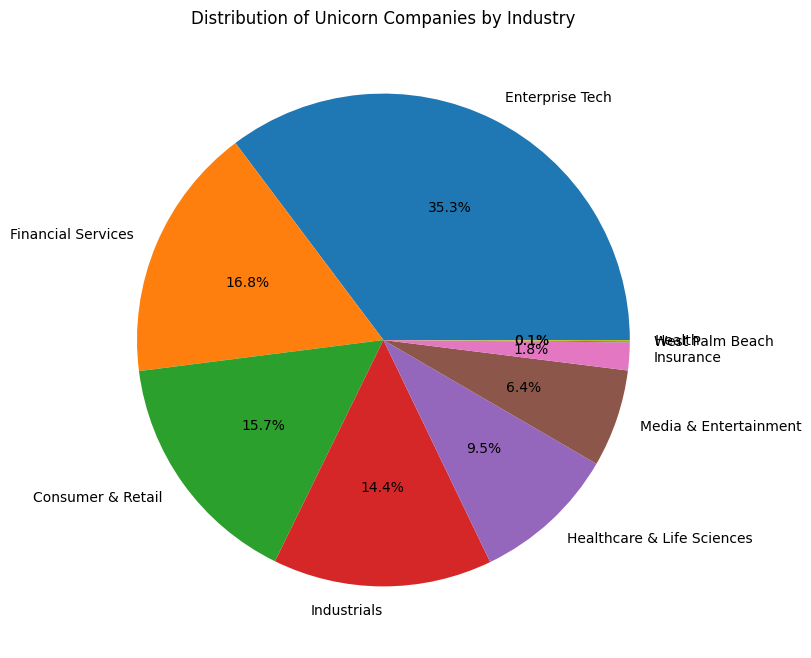

In [51]:
# =====================================================
# 4. 산업 분야별 유니콘 기업 비중
# =====================================================

industry_count = df['Industry'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    industry_count,
    labels=industry_count.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Unicorn Companies by Industry')

plt.show()

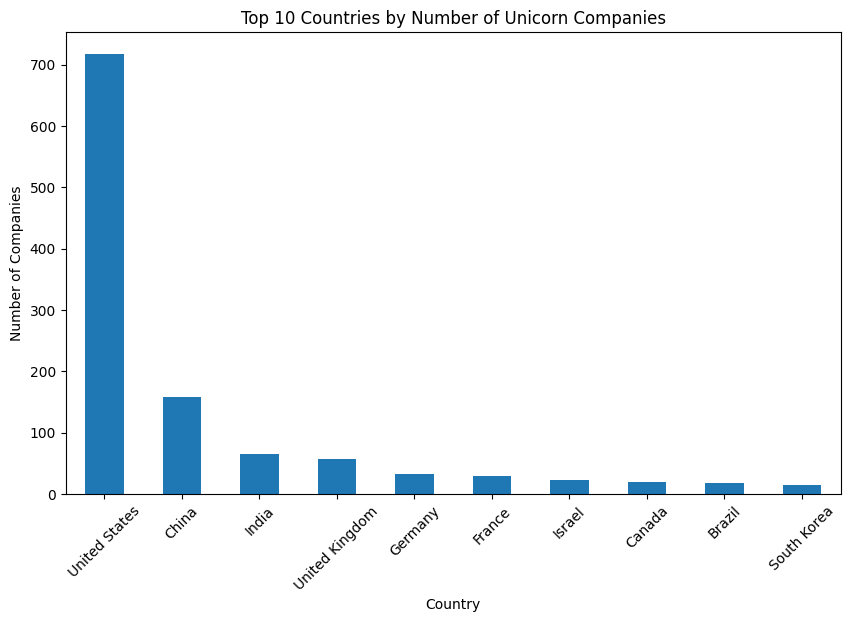

In [52]:
# =====================================================
# 5. 국가별 유니콘 기업 수 TOP10
# =====================================================

country_top10 = df['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))

country_top10.plot(kind='bar')

plt.title('Top 10 Countries by Number of Unicorn Companies')

plt.xlabel('Country')

plt.ylabel('Number of Companies')

plt.xticks(rotation=45)

plt.show()

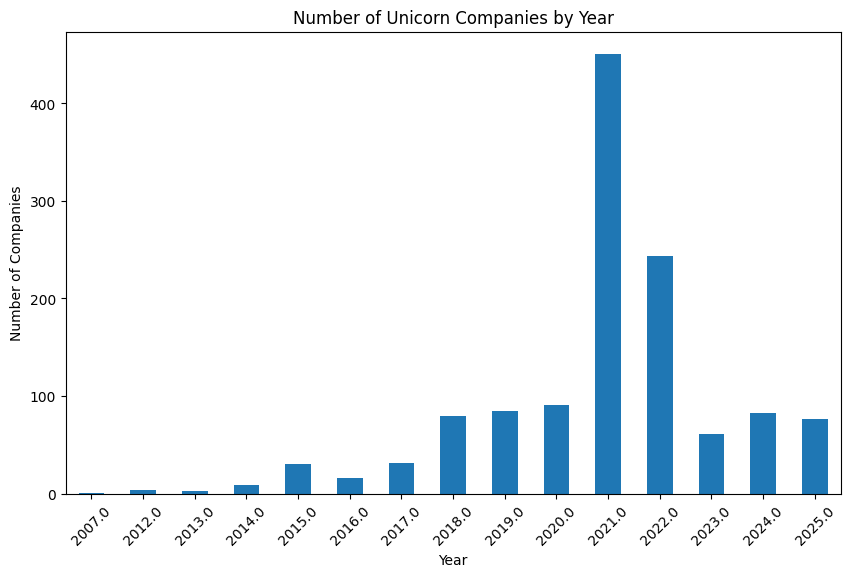

In [53]:
# =====================================================
# 6. 연도별 유니콘 기업 수
# =====================================================

year_count = df['Year'].value_counts()

# 연도순 정렬

year_count = year_count.sort_index()


plt.figure(figsize=(10,6))

year_count.plot(kind='bar')


plt.title('Number of Unicorn Companies by Year')

plt.xlabel('Year')

plt.ylabel('Number of Companies')

plt.xticks(rotation=45)

plt.show()

In [60]:
# =====================================================
# 7.1 Enterprise Tech와 Financial Services 데이터 분리
# =====================================================

enterprise = df[
    df['Industry'] == 'Enterprise Tech'
]

financial = df[
    df['Industry'] == 'Financial Services'
]


print("=== 데이터 개수 ===")

print("Enterprise Tech :", len(enterprise))

print("Financial Services :", len(financial))

=== 데이터 개수 ===
Enterprise Tech : 446
Financial Services : 212


In [61]:
# =====================================================
# 7.2 기업 수 비교
# =====================================================

print("=== 기업 수 비교 ===")

print("Enterprise Tech :",
      enterprise['Company'].nunique())

print("Financial Services :",
      financial['Company'].nunique())

=== 기업 수 비교 ===
Enterprise Tech : 446
Financial Services : 212


In [62]:
# =====================================================
# 7.3 평균 등록 연도 비교
# =====================================================

print("=== 평균 등록 연도 ===")

print("Enterprise Tech :",
      round(
          enterprise['Year'].mean(),
          2
      ))

print("Financial Services :",
      round(
          financial['Year'].mean(),
          2
      ))

=== 평균 등록 연도 ===
Enterprise Tech : 2021.48
Financial Services : 2020.95


In [63]:
# =====================================================
# 7.4 최초 및 최근 등록 연도 비교
# =====================================================

print("=== Enterprise Tech ===")

print("최초 등록 연도 :",
      enterprise['Year'].min())

print("최근 등록 연도 :",
      enterprise['Year'].max())


print("\n=== Financial Services ===")

print("최초 등록 연도 :",
      financial['Year'].min())

print("최근 등록 연도 :",
      financial['Year'].max())

=== Enterprise Tech ===
최초 등록 연도 : 2013.0
최근 등록 연도 : 2025.0

=== Financial Services ===
최초 등록 연도 : 2012.0
최근 등록 연도 : 2025.0


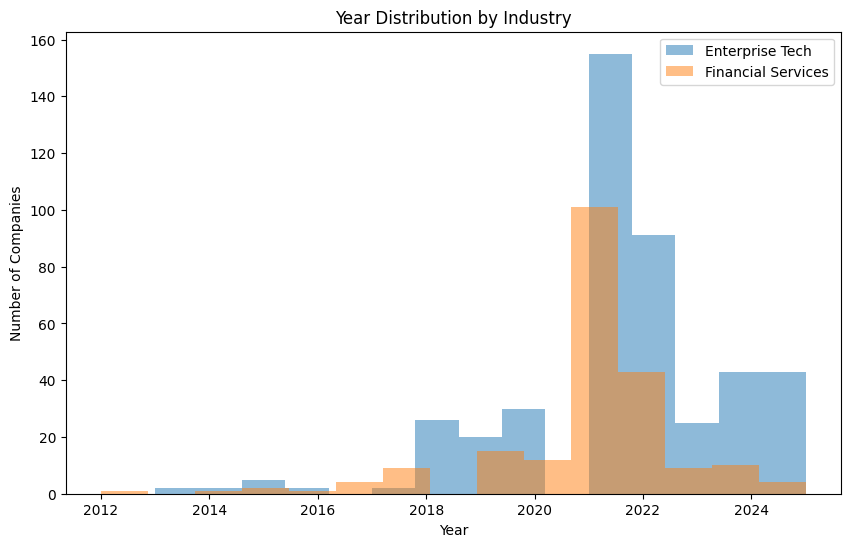

In [64]:
# =====================================================
# 7.5 산업별 연도 분포 시각화
# =====================================================

plt.figure(figsize=(10,6))

plt.hist(
    enterprise['Year'],
    bins=15,
    alpha=0.5,
    label='Enterprise Tech'
)

plt.hist(
    financial['Year'],
    bins=15,
    alpha=0.5,
    label='Financial Services'
)

plt.title(
    'Year Distribution by Industry'
)

plt.xlabel('Year')

plt.ylabel('Number of Companies')

plt.legend()

plt.show()

In [65]:
# =====================================================
# 8.1 미국과 미국 외 기업 분리
# =====================================================

usa = df[
    df['Country'] == 'United States'
]

non_usa = df[
    df['Country'] != 'United States'
]


print("=== 데이터 개수 ===")

print("미국 :", len(usa))

print("미국 외 :", len(non_usa))

=== 데이터 개수 ===
미국 : 717
미국 외 : 548


In [66]:
# =====================================================
# 8.2 기업 수 비교
# =====================================================

print("=== 기업 수 비교 ===")

print("미국 :",
      usa['Company'].nunique())

print("미국 외 :",
      non_usa['Company'].nunique())

=== 기업 수 비교 ===
미국 : 717
미국 외 : 548


In [67]:
# =====================================================
# 8.3 평균 등록 연도 비교
# =====================================================

print("=== 평균 등록 연도 ===")

print("미국 :",
      round(
          usa['Year'].mean(),
          2
      ))

print("미국 외 :",
      round(
          non_usa['Year'].mean(),
          2
      ))

=== 평균 등록 연도 ===
미국 : 2021.26
미국 외 : 2020.48


In [68]:
# =====================================================
# 8.4 최초 및 최근 등록 연도 비교
# =====================================================

print("=== 미국 ===")

print("최초 등록 연도 :",
      usa['Year'].min())

print("최근 등록 연도 :",
      usa['Year'].max())


print("\n=== 미국 외 ===")

print("최초 등록 연도 :",
      non_usa['Year'].min())

print("최근 등록 연도 :",
      non_usa['Year'].max())

=== 미국 ===
최초 등록 연도 : 2012.0
최근 등록 연도 : 2025.0

=== 미국 외 ===
최초 등록 연도 : 2007.0
최근 등록 연도 : 2025.0


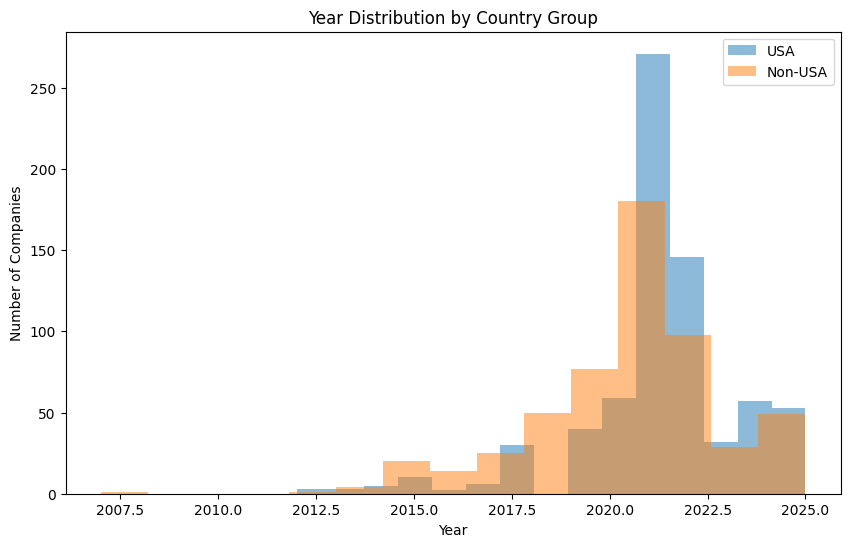

In [69]:
# =====================================================
# 8.5 미국과 미국 외 연도 분포 시각화
# =====================================================

plt.figure(figsize=(10,6))

plt.hist(
    usa['Year'],
    bins=15,
    alpha=0.5,
    label='USA'
)

plt.hist(
    non_usa['Year'],
    bins=15,
    alpha=0.5,
    label='Non-USA'
)

plt.title(
    'Year Distribution by Country Group'
)

plt.xlabel('Year')

plt.ylabel('Number of Companies')

plt.legend()

plt.show()

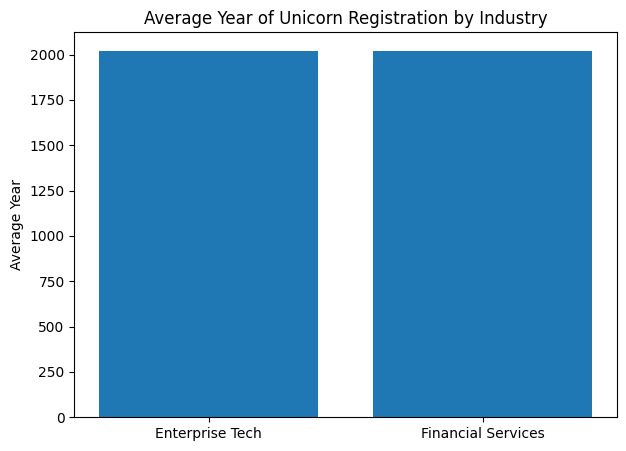

In [58]:
# =====================================================
# 11. 산업별 평균 등록 연도 비교
# =====================================================

industry_avg = {
    'Enterprise Tech':
        enterprise['Year'].mean(),

    'Financial Services':
        financial['Year'].mean()
}


plt.figure(figsize=(7,5))

plt.bar(
    industry_avg.keys(),
    industry_avg.values()
)

plt.title('Average Year of Unicorn Registration by Industry')

plt.ylabel('Average Year')

plt.show()

In [56]:
# =====================================================
# 9. 미국과 미국 외 기업 데이터 분리
# =====================================================

# 미국 기업

usa = df[
    df['Country'] == 'United States'
]


# 미국 외 기업

non_usa = df[
    df['Country'] != 'United States'
]


print("=== 데이터 개수 ===")

print("미국 :", len(usa))

print("미국 외 :", len(non_usa))

=== 데이터 개수 ===
미국 : 717
미국 외 : 548


In [57]:
# =====================================================
# 10. 미국과 미국 외 기업 비교
# =====================================================

print("=== 미국 ===")

print("기업 수 :", len(usa))

print("평균 등록 연도 :",
      round(usa['Year'].mean(),2))

print("최초 등록 연도 :",
      usa['Year'].min())

print("최근 등록 연도 :",
      usa['Year'].max())



print("\n=== 미국 외 ===")

print("기업 수 :", len(non_usa))

print("평균 등록 연도 :",
      round(non_usa['Year'].mean(),2))

print("최초 등록 연도 :",
      non_usa['Year'].min())

print("최근 등록 연도 :",
      non_usa['Year'].max())

=== 미국 ===
기업 수 : 717
평균 등록 연도 : 2021.26
최초 등록 연도 : 2012.0
최근 등록 연도 : 2025.0

=== 미국 외 ===
기업 수 : 548
평균 등록 연도 : 2020.48
최초 등록 연도 : 2007.0
최근 등록 연도 : 2025.0


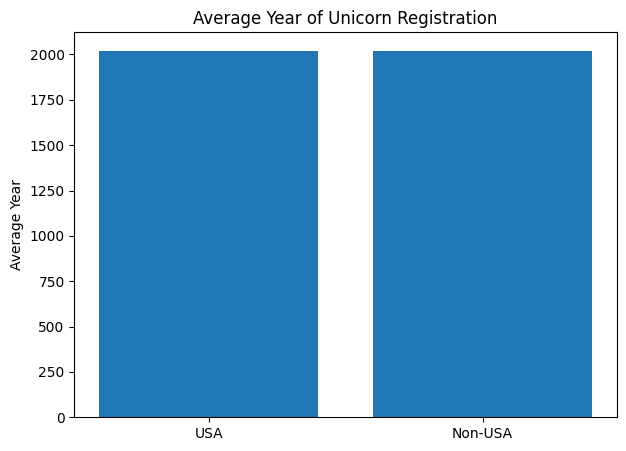

In [59]:
# =====================================================
# 12. 미국과 미국 외 평균 등록 연도 비교
# =====================================================

country_avg = {
    'USA':
        usa['Year'].mean(),

    'Non-USA':
        non_usa['Year'].mean()
}


plt.figure(figsize=(7,5))

plt.bar(
    country_avg.keys(),
    country_avg.values()
)

plt.title('Average Year of Unicorn Registration')

plt.ylabel('Average Year')

plt.show()